# LeiGS 2026 — Proctor Prediction Challenge · v3 (PINN)

**Goal**: Predict `proctor_mdd_g_cm3` (MDD) and `proctor_owc_pct` (OWC) from soil classification features.

**v3 approach**: Physics-Informed Neural Network (PINN) with twin heads.

**Physics constraint**: Zero-Air-Voids (ZAV) saturation line
$$\rho_{d,sat}(w) = \frac{\rho_s}{1 + \frac{w}{100} \cdot \frac{\rho_s}{\rho_w}}$$
MDD must lie **below** this line.  At OWC, the degree of saturation $S_r \approx 0.7{-}1.0$.

**Metric**: NMAE = 0.5×(MAE_mdd/IQR_mdd) + 0.5×(MAE_owc/IQR_owc)

## Section 0: Setup & Imports

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import KFold

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)

IQR_MDD = 0.198
IQR_OWC = 3.860
RHO_W   = 1.0   # g/cm^3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print('All imports OK')

Device: cpu
PyTorch: 2.12.1
All imports OK


## Section 1: Data Loading

In [2]:
train_raw  = pd.read_csv('../data/train.csv')
test_raw   = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../sample_submission.csv')

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head(3)

Train: (201, 25)  |  Test: (87, 23)


,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,51.68,2.068,8.06,150,2.650,NaN,NaN,NaN,NaN,NaN
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,65.49,2.037,10.42,100,2.690,NaN,NaN,NaN,NaN,1.3
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,81.40,2.051,10.94,100,2.722,1.400000e-10,30.0,26.45,13.75,NaN


## Section 2: Preprocessing

In [3]:
TARGET_COLS = ['proctor_mdd_g_cm3', 'proctor_owc_pct']

PSD_D_COLS = [
    'psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
    'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
    'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
    'psd_size_at_d95_mm', 'psd_size_at_d98_mm'
]

HIGH_MISSING = [
    'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct',
    'hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'loss_on_ignition_pct'
]

def preprocess(df, medians=None, fit=False):
    df = df.copy()
    df['psd_has_sedimentation'] = df['psd_has_sedimentation'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).astype(float)
    for col in PSD_D_COLS + HIGH_MISSING + [
        'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
        'psd_passing_at_2mm_pct', 'grain_density_g_cm3', 'proctor_diam_mm'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in HIGH_MISSING:
        df[f'{col}_missing'] = df[col].isna().astype(int)
    if fit:
        medians = {col: df[col].median() for col in HIGH_MISSING}
    for col in HIGH_MISSING:
        df[col] = df[col].fillna(medians[col])
    return df, medians

train_pp, medians = preprocess(train_raw, fit=True)
test_pp, _        = preprocess(test_raw, medians=medians, fit=False)
print('Preprocessing complete.')

Preprocessing complete.


## Section 3: Feature Engineering

In [4]:
def engineer_features(df):
    df = df.copy()
    D10 = df['psd_size_at_d10_mm'].replace(0, np.nan)
    D30 = df['psd_size_at_d30_mm']
    D60 = df['psd_size_at_d60_mm'].replace(0, np.nan)

    df['feat_cu']     = D60 / D10                            # coefficient of uniformity
    df['feat_cc']     = (D30 ** 2) / (D60 * D10)            # coefficient of curvature
    df['feat_log_cu'] = np.log1p(df['feat_cu'])
    df['feat_pi']     = df['atterberg_liquid_limit_pct'] - df['atterberg_plastic_limit_pct']

    df['feat_sand_pct']   = (df['psd_passing_at_2mm_pct'] - df['psd_passing_at_0_063mm_pct']).clip(lower=0)
    df['feat_gravel_pct'] = (100 - df['psd_passing_at_2mm_pct']).clip(lower=0)
    df['feat_clay_to_fines_ratio'] = (
        df['psd_passing_at_0_002mm_pct']
        / df['psd_passing_at_0_063mm_pct'].replace(0, np.nan)
    ).fillna(0)
    df['feat_soil_type'] = pd.cut(
        df['psd_passing_at_0_063mm_pct'], bins=[-1, 10, 40, 101], labels=[0, 1, 2]
    ).astype(float)

    rho_s = df['grain_density_g_cm3']
    w_est = (df['psd_passing_at_0_063mm_pct'] / 10).clip(lower=3)
    df['feat_sat_mdd_proxy'] = rho_s / (1 + (w_est / 100) * rho_s / RHO_W)
    df['feat_d50'] = df['psd_size_at_d50_mm']

    for col in PSD_D_COLS:
        df[f'log_{col}'] = np.log1p(df[col])
    df['log_hyd_cond_kf_m_s'] = np.log1p(df['hyd_cond_kf_m_s'])
    return df

train_fe = engineer_features(train_pp)
test_fe  = engineer_features(test_pp)

EXCLUDE      = ['id'] + TARGET_COLS
FEATURE_COLS = [c for c in train_fe.columns if c not in EXCLUDE]

X_train = train_fe[FEATURE_COLS].values.astype(np.float32)
y_mdd   = train_fe['proctor_mdd_g_cm3'].values.astype(np.float32)
y_owc   = train_fe['proctor_owc_pct'].values.astype(np.float32)
X_test  = test_fe[FEATURE_COLS].values.astype(np.float32)

# Grain density for physics constraints
rho_s_train = train_fe['grain_density_g_cm3'].fillna(2.65).values.astype(np.float32)
rho_s_test  = test_fe['grain_density_g_cm3'].fillna(2.65).values.astype(np.float32)

# Impute remaining NaNs with column medians
col_medians = np.nanmedian(X_train, axis=0)
nan_mask    = np.isnan(X_train)
X_train[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
nan_mask_te = np.isnan(X_test)
X_test[nan_mask_te] = np.take(col_medians, np.where(nan_mask_te)[1])

print(f'Features: {len(FEATURE_COLS)}  |  X_train: {X_train.shape}  X_test: {X_test.shape}')

Features: 49  |  X_train: (201, 49)  X_test: (87, 49)


## Section 4: Competition Metric

In [5]:
def nmae(y_mdd_true, y_owc_true, y_mdd_pred, y_owc_pred):
    mae_mdd = np.mean(np.abs(y_mdd_true - y_mdd_pred))
    mae_owc = np.mean(np.abs(y_owc_true - y_owc_pred))
    return 0.5 * (mae_mdd / IQR_MDD) + 0.5 * (mae_owc / IQR_OWC)

print('NMAE metric defined.')

NMAE metric defined.


## Section 5: PINN Model Architecture

Shared trunk + twin heads (one for MDD, one for OWC).
- **LayerNorm** after each linear for training stability on small datasets.
- **GELU** activations (smooth, empirically better than ReLU for regression).
- **Dual heads** allow each target to learn its own final representation.

In [6]:
class ProctorPINN(nn.Module):
    """
    Physics-Informed Neural Network for Proctor compaction prediction.

    The ZAV (Zero-Air-Voids) saturation constraint is enforced via the loss,
    not hard-coded into the architecture — this lets gradients flow freely
    while biasing the network toward physically admissible solutions.
    """
    def __init__(self, n_in, hidden=(256, 128, 64), p_drop=0.15):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [
                nn.Linear(d, h),
                nn.LayerNorm(h),
                nn.GELU(),
                nn.Dropout(p_drop)
            ]
            d = h
        self.trunk    = nn.Sequential(*layers)
        self.mdd_head = nn.Sequential(nn.Linear(d, 32), nn.GELU(), nn.Linear(32, 1))
        self.owc_head = nn.Sequential(nn.Linear(d, 32), nn.GELU(), nn.Linear(32, 1))

    def forward(self, x):
        h   = self.trunk(x)
        mdd = self.mdd_head(h).squeeze(-1)
        owc = self.owc_head(h).squeeze(-1)
        return mdd, owc  # both in normalized space


# Quick sanity check
n_in   = X_train.shape[1]
_dummy = ProctorPINN(n_in)
_x     = torch.zeros(4, n_in)
_mdd, _owc = _dummy(_x)
print(f'Model OK  |  n_in={n_in}  |  out shapes: mdd={_mdd.shape}  owc={_owc.shape}')
n_params = sum(p.numel() for p in _dummy.parameters())
print(f'Total parameters: {n_params:,}')

Model OK  |  n_in=49  |  out shapes: mdd=torch.Size([4])  owc=torch.Size([4])
Total parameters: 59,074


## Section 6: Physics-Informed Loss

Two physics terms added to the standard Huber data loss:

1. **ZAV bound** — penalises predictions above the saturation line:
   $\mathcal{L}_{\text{ZAV}} = \mathbb{E}[\max(0,\, \rho_d - \rho_{d,sat})^2]$

2. **Degree of saturation** — keeps $S_r \in [0.7, 1.0]$, consistent with field-compacted soils:
   $e = \rho_s/\rho_d - 1$,  $S_r = (w/100 \cdot \rho_s) / (e \cdot \rho_w)$

In [7]:
def saturation_mdd(owc_pct, grain_density, rho_w=RHO_W):
    """Zero-Air-Voids dry density: rho_d_sat = rho_s / (1 + w/100 * rho_s / rho_w)"""
    return grain_density / (1.0 + (owc_pct / 100.0) * grain_density / rho_w)


def compute_physics_loss(mdd_pred, owc_pred, grain_density,
                         w_bound=5.0, w_sr=0.5, sr_lo=0.70, sr_hi=1.0):
    """
    Composite physics penalty.

    Args:
        mdd_pred:      predicted dry density (g/cm^3), physical units
        owc_pred:      predicted optimum water content (%), physical units
        grain_density: grain (particle) density rho_s (g/cm^3)
        w_bound:       weight of the ZAV saturation-bound penalty
        w_sr:          weight of the degree-of-saturation penalty
        sr_lo/sr_hi:   acceptable Sr range
    """
    # (1) ZAV bound: MDD must not exceed the saturation line
    rho_sat   = saturation_mdd(owc_pred, grain_density)
    violation = F.relu(mdd_pred - rho_sat)
    loss_bound = (violation ** 2).mean()

    # (2) Degree of saturation: void ratio e = rho_s/rho_d - 1
    #     Sr = w/100 * rho_s / (e * rho_w)
    e  = (grain_density / mdd_pred.clamp(min=0.5)) - 1.0
    Sr = (owc_pred / 100.0 * grain_density) / (e.clamp(min=1e-3) * RHO_W)
    loss_sr = (F.relu(sr_lo - Sr) + F.relu(Sr - sr_hi)).pow(2).mean()

    return w_bound * loss_bound + w_sr * loss_sr


print('Physics loss functions defined.')

Physics loss functions defined.


## Section 7: Training Utilities

In [8]:
def train_one_model(
    X_tr, y_mdd_tr, y_owc_tr, rho_s_tr,
    X_val=None, y_mdd_val=None, y_owc_val=None,
    n_epochs=1500, lr=1e-3, batch_size=32,
    w_bound=5.0, w_sr=0.5, p_drop=0.15,
    hidden=(256, 128, 64), verbose_every=300
):
    """
    Train a single PINN instance.

    Returns (model, x_mu, x_sd, y_mu, y_sd, best_val_nmae, history).
    The preprocessing stats are needed at inference time to rescale inputs/outputs.
    """
    n_in = X_tr.shape[1]

    # Feature standardization (fit on training split only)
    x_mu = X_tr.mean(axis=0)
    x_sd = X_tr.std(axis=0) + 1e-8
    X_tr_n = (X_tr - x_mu) / x_sd

    # Target normalization: stack [mdd, owc]
    y_tr = np.stack([y_mdd_tr, y_owc_tr], axis=1)  # (N, 2)
    y_mu = y_tr.mean(axis=0)
    y_sd = y_tr.std(axis=0) + 1e-8
    y_tr_n = (y_tr - y_mu) / y_sd

    # Tensors
    Xt     = torch.tensor(X_tr_n, dtype=torch.float32, device=DEVICE)
    Yt     = torch.tensor(y_tr_n, dtype=torch.float32, device=DEVICE)
    rho_t  = torch.tensor(rho_s_tr, dtype=torch.float32, device=DEVICE)
    y_mu_t = torch.tensor(y_mu, dtype=torch.float32, device=DEVICE)
    y_sd_t = torch.tensor(y_sd, dtype=torch.float32, device=DEVICE)

    dataset = TensorDataset(Xt, Yt, rho_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    model     = ProctorPINN(n_in, hidden=hidden, p_drop=p_drop).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_val   = np.inf
    best_state = None
    history    = {'train_loss': [], 'val_nmae': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb, rb in loader:
            optimizer.zero_grad()
            mdd_n, owc_n = model(xb)

            # Huber data loss (robust to outliers)
            loss_data = (
                F.smooth_l1_loss(mdd_n, yb[:, 0]) +
                F.smooth_l1_loss(owc_n, yb[:, 1])
            )

            # De-normalize to physical units for the physics penalty
            mdd_phys = mdd_n * y_sd_t[0] + y_mu_t[0]
            owc_phys = (owc_n * y_sd_t[1] + y_mu_t[1]).clamp(min=0.5)
            loss_phys = compute_physics_loss(
                mdd_phys, owc_phys, rb, w_bound=w_bound, w_sr=w_sr
            )

            loss = loss_data + loss_phys
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        history['train_loss'].append(epoch_loss / len(loader))

        # Evaluate on validation set
        if X_val is not None and ((epoch + 1) % verbose_every == 0 or epoch == n_epochs - 1):
            model.eval()
            X_val_n = (X_val - x_mu) / x_sd
            with torch.no_grad():
                Xv = torch.tensor(X_val_n, dtype=torch.float32, device=DEVICE)
                mdd_n_v, owc_n_v = model(Xv)
                mdd_pred = mdd_n_v.cpu().numpy() * y_sd[0] + y_mu[0]
                owc_pred = owc_n_v.cpu().numpy() * y_sd[1] + y_mu[1]

            val_score = nmae(y_mdd_val, y_owc_val, mdd_pred, owc_pred)
            history['val_nmae'].append(val_score)

            if val_score < best_val:
                best_val   = val_score
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            print(f'  Epoch {epoch+1:4d}/{n_epochs} | '
                  f'train_loss={epoch_loss/len(loader):.4f} | '
                  f'val_NMAE={val_score:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        # No validation — save last state
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    return model, x_mu, x_sd, y_mu, y_sd, best_val, history


print('Training utilities defined.')

Training utilities defined.


## Section 8: 5-Fold Cross-Validation

In [9]:
N_FOLDS    = 5
N_EPOCHS   = 1500
LR         = 1e-3
BATCH_SIZE = 32
W_BOUND    = 5.0
W_SR       = 0.5
P_DROP     = 0.15
HIDDEN     = (256, 128, 64)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_scores  = []
fold_models  = []   # store (model, x_mu, x_sd, y_mu, y_sd) per fold
fold_history = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} (train={len(tr_idx)}, val={len(val_idx)}) ===')

    m, x_mu, x_sd, y_mu, y_sd, val_nmae, hist = train_one_model(
        X_train[tr_idx], y_mdd[tr_idx], y_owc[tr_idx], rho_s_train[tr_idx],
        X_val=X_train[val_idx], y_mdd_val=y_mdd[val_idx], y_owc_val=y_owc[val_idx],
        n_epochs=N_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
        w_bound=W_BOUND, w_sr=W_SR, p_drop=P_DROP, hidden=HIDDEN,
        verbose_every=300
    )

    fold_scores.append(val_nmae)
    fold_models.append((m, x_mu, x_sd, y_mu, y_sd))
    fold_history.append(hist)
    print(f'  -> Best val NMAE: {val_nmae:.4f}')

print(f'\n5-fold CV NMAE: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'Per-fold:       {[round(s, 4) for s in fold_scores]}')


=== Fold 1/5 (train=160, val=41) ===
  Epoch  300/1500 | train_loss=0.0182 | val_NMAE=0.2881
  Epoch  600/1500 | train_loss=0.0126 | val_NMAE=0.2827
  Epoch  900/1500 | train_loss=0.0100 | val_NMAE=0.2745
  Epoch 1200/1500 | train_loss=0.0078 | val_NMAE=0.2781
  Epoch 1500/1500 | train_loss=0.0070 | val_NMAE=0.2778
  -> Best val NMAE: 0.2745

=== Fold 2/5 (train=161, val=40) ===
  Epoch  300/1500 | train_loss=0.0240 | val_NMAE=0.3016
  Epoch  600/1500 | train_loss=0.0149 | val_NMAE=0.2995
  Epoch  900/1500 | train_loss=0.0180 | val_NMAE=0.3132
  Epoch 1200/1500 | train_loss=0.0097 | val_NMAE=0.3098
  Epoch 1500/1500 | train_loss=0.0125 | val_NMAE=0.3056
  -> Best val NMAE: 0.2995

=== Fold 3/5 (train=161, val=40) ===
  Epoch  300/1500 | train_loss=0.0242 | val_NMAE=0.2960
  Epoch  600/1500 | train_loss=0.0141 | val_NMAE=0.2894
  Epoch  900/1500 | train_loss=0.0142 | val_NMAE=0.2920
  Epoch 1200/1500 | train_loss=0.0130 | val_NMAE=0.2806
  Epoch 1500/1500 | train_loss=0.0106 | val_NMAE

### Training Curve Visualisation

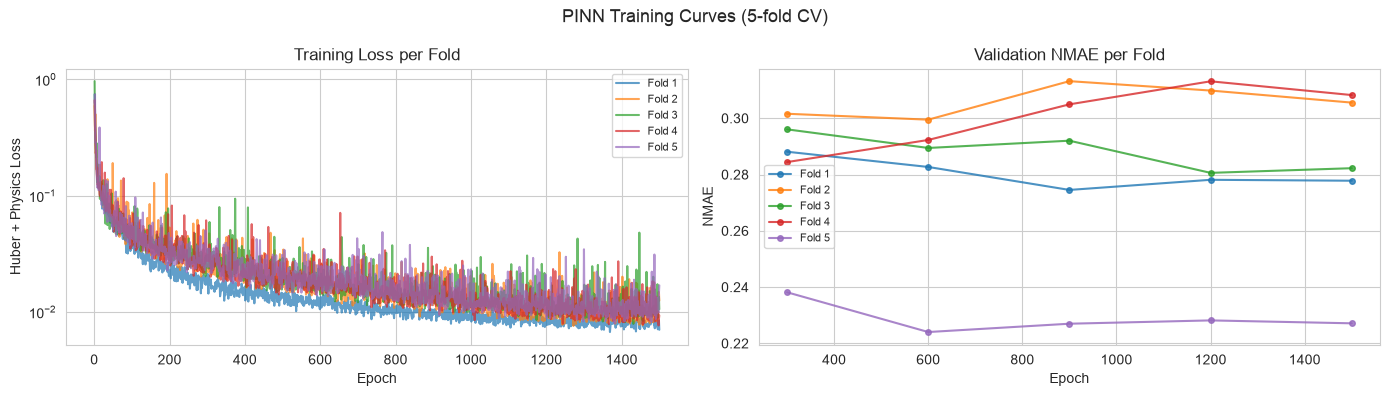

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for fold_i, hist in enumerate(fold_history):
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], alpha=0.7, label=f'Fold {fold_i+1}')

axes[0].set_title('Training Loss per Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber + Physics Loss')
axes[0].legend(fontsize=8)
axes[0].set_yscale('log')

for fold_i, hist in enumerate(fold_history):
    if hist['val_nmae']:
        check_epochs = list(range(300, N_EPOCHS + 1, 300))
        if len(check_epochs) > len(hist['val_nmae']):
            check_epochs = check_epochs[:len(hist['val_nmae'])]
        axes[1].plot(check_epochs, hist['val_nmae'], marker='o', markersize=4,
                     alpha=0.8, label=f'Fold {fold_i+1}')

axes[1].set_title('Validation NMAE per Fold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('NMAE')
axes[1].legend(fontsize=8)

plt.suptitle('PINN Training Curves (5-fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

## Section 9: Final Model Training & Model Save

Train on the full dataset (all 201 rows) with more epochs for a stronger final model.
Save a self-contained checkpoint to `../models/pinn_v3_model.pt` that includes
all preprocessing stats needed for inference.

In [11]:
MODEL_PATH = Path('../models/pinn_v3_model.pt')
MODEL_PATH.parent.mkdir(exist_ok=True)

print('Training final model on full dataset (2000 epochs)...')

final_model, x_mu_f, x_sd_f, y_mu_f, y_sd_f, _, final_history = train_one_model(
    X_train, y_mdd, y_owc, rho_s_train,
    n_epochs=2000, lr=LR, batch_size=BATCH_SIZE,
    w_bound=W_BOUND, w_sr=W_SR, p_drop=P_DROP, hidden=HIDDEN,
    verbose_every=500
)

# Self-contained checkpoint
ckpt = {
    'state_dict':   final_model.state_dict(),
    'feature_cols': FEATURE_COLS,
    'medians':      medians,          # dict of HIGH_MISSING column medians
    'col_medians':  col_medians,      # numpy array for NaN imputation in feature matrix
    'x_mu':         x_mu_f,
    'x_sd':         x_sd_f,
    'y_mu':         y_mu_f,           # [mdd_mu, owc_mu]
    'y_sd':         y_sd_f,           # [mdd_sd, owc_sd]
    'n_in':         X_train.shape[1],
    'hidden':       HIDDEN,
    'dropout':      P_DROP,
    'targets':      ['proctor_mdd_g_cm3', 'proctor_owc_pct'],
    'iqr_mdd':      IQR_MDD,
    'iqr_owc':      IQR_OWC,
    'cv_nmae_mean': float(np.mean(fold_scores)),
    'cv_nmae_std':  float(np.std(fold_scores)),
    'pinn_version': 'v3',
}
torch.save(ckpt, MODEL_PATH)
print(f'\nModel checkpoint saved -> {MODEL_PATH}')
print(f'CV NMAE: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

Training final model on full dataset (2000 epochs)...

Model checkpoint saved -> ../models/pinn_v3_model.pt
CV NMAE: 0.2726 ± 0.0257


## Section 10: Inference & Submission

In [12]:
def predict(model, X, x_mu, x_sd, y_mu, y_sd, grain_density,
            rho_w=RHO_W, safety=0.999):
    """Run inference and enforce the saturation constraint on MDD."""
    model.eval()
    X_n = (X - x_mu) / x_sd
    with torch.no_grad():
        Xt  = torch.tensor(X_n, dtype=torch.float32, device=DEVICE)
        mdd_n, owc_n = model(Xt)
        pred_mdd = mdd_n.cpu().numpy() * y_sd[0] + y_mu[0]
        pred_owc = owc_n.cpu().numpy() * y_sd[1] + y_mu[1]

    pred_owc = np.clip(pred_owc, 2.0, 35.0)
    rho_sat  = grain_density / (1.0 + (pred_owc / 100.0) * grain_density / rho_w)
    pred_mdd = np.minimum(pred_mdd, rho_sat * safety)
    pred_mdd = np.clip(pred_mdd, 1.4, 2.5)
    return pred_mdd, pred_owc


# (a) Single final model predictions
pred_mdd_single, pred_owc_single = predict(
    final_model, X_test, x_mu_f, x_sd_f, y_mu_f, y_sd_f, rho_s_test
)

# (b) Ensemble predictions (average of all fold models + final model)
all_mdd, all_owc = [pred_mdd_single], [pred_owc_single]
for m, x_mu_k, x_sd_k, y_mu_k, y_sd_k in fold_models:
    mdd_k, owc_k = predict(m, X_test, x_mu_k, x_sd_k, y_mu_k, y_sd_k, rho_s_test)
    all_mdd.append(mdd_k)
    all_owc.append(owc_k)

pred_mdd_ens = np.mean(all_mdd, axis=0)
pred_owc_ens = np.mean(all_owc, axis=0)

# Re-apply constraint on ensemble (small numerical caution)
rho_sat_ens  = rho_s_test / (1.0 + (pred_owc_ens / 100.0) * rho_s_test / RHO_W)
pred_mdd_ens = np.minimum(pred_mdd_ens, rho_sat_ens * 0.999)
pred_mdd_ens = np.clip(pred_mdd_ens, 1.4, 2.5)
pred_owc_ens = np.clip(pred_owc_ens, 2.0, 35.0)

print('Predictions generated.')
print(f'MDD range: [{pred_mdd_ens.min():.3f}, {pred_mdd_ens.max():.3f}] g/cm³')
print(f'OWC range: [{pred_owc_ens.min():.2f}, {pred_owc_ens.max():.2f}] %')

Predictions generated.
MDD range: [1.721, 2.174] g/cm³
OWC range: [5.64, 17.69] %


In [13]:
# Build and validate submission (using ensemble predictions)
submission = pd.DataFrame({
    'id':               test_raw['id'],
    'proctor_owc_pct':  np.round(pred_owc_ens, 3),
    'proctor_mdd_g_cm3': np.round(pred_mdd_ens, 4)
})

assert list(submission.columns) == ['id', 'proctor_owc_pct', 'proctor_mdd_g_cm3']
assert len(submission) == len(test_raw)
assert (submission['proctor_mdd_g_cm3'] > 1.4).all()
assert (submission['proctor_mdd_g_cm3'] < 2.5).all()
assert (submission['proctor_owc_pct'] > 2.0).all()
assert (submission['proctor_owc_pct'] < 35.0).all()

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
out_path  = f'../submissions/submission_{timestamp}_v3_pinn.csv'
submission.to_csv(out_path, index=False)
print(f'All checks passed.')
print(f'Submission saved → {out_path}')
submission.describe().round(3)

All checks passed.
Submission saved → ../submissions/submission_20260630_1621_v3_pinn.csv


,id,proctor_owc_pct,proctor_mdd_g_cm3
count,87.000,87.000,87.000
mean,244.000,9.893,1.984
std,25.259,2.928,0.120
min,201.000,5.645,1.721
25%,222.500,7.769,1.891
50%,244.000,9.141,2.006
75%,265.500,10.651,2.081
max,287.000,17.688,2.174


## Section 11: Prediction Distribution Visualisation

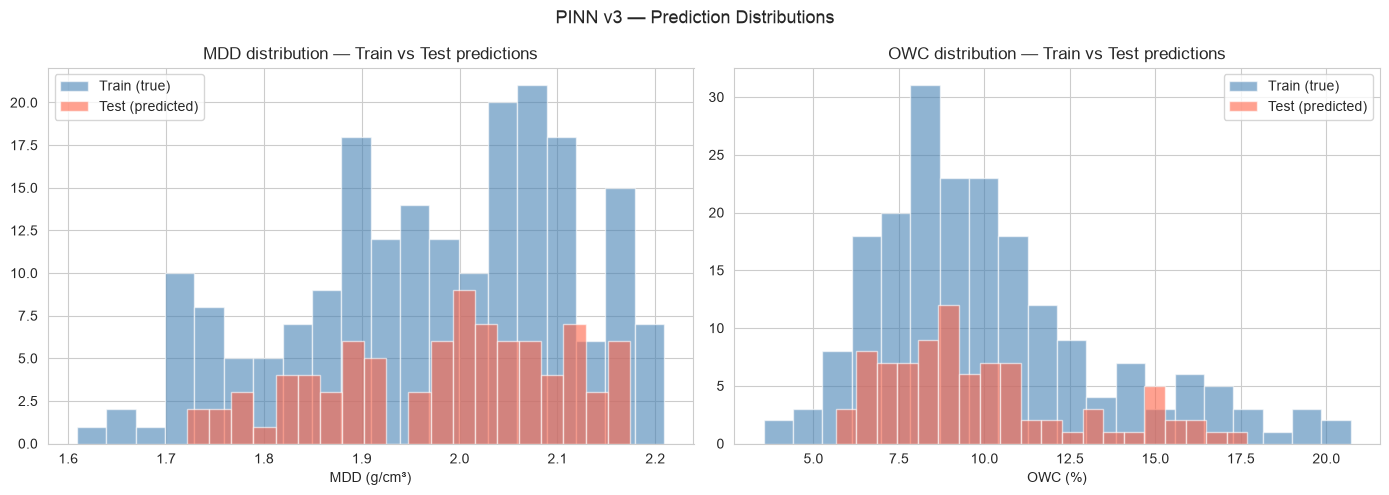

ZAV violations in test predictions: 0 / 87
Degree of saturation range: [0.437, 0.914]
Sr within [0.7, 1.0]: 70.1% of samples


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDD
axes[0].hist(y_mdd, bins=20, alpha=0.6, label='Train (true)', color='steelblue')
axes[0].hist(pred_mdd_ens, bins=20, alpha=0.6, label='Test (predicted)', color='tomato')
axes[0].set_title('MDD distribution — Train vs Test predictions')
axes[0].set_xlabel('MDD (g/cm³)')
axes[0].legend()

# OWC
axes[1].hist(y_owc, bins=20, alpha=0.6, label='Train (true)', color='steelblue')
axes[1].hist(pred_owc_ens, bins=20, alpha=0.6, label='Test (predicted)', color='tomato')
axes[1].set_title('OWC distribution — Train vs Test predictions')
axes[1].set_xlabel('OWC (%)')
axes[1].legend()

plt.suptitle('PINN v3 — Prediction Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Saturation check: verify ZAV constraint is satisfied
rho_zav = rho_s_test / (1.0 + (pred_owc_ens / 100.0) * rho_s_test / RHO_W)
n_violations = np.sum(pred_mdd_ens > rho_zav)
print(f'ZAV violations in test predictions: {n_violations} / {len(pred_mdd_ens)}')

# Degree of saturation check
e_test  = rho_s_test / pred_mdd_ens - 1
Sr_test = (pred_owc_ens / 100.0 * rho_s_test) / (e_test * RHO_W)
print(f'Degree of saturation range: [{Sr_test.min():.3f}, {Sr_test.max():.3f}]')
print(f'Sr within [0.7, 1.0]: {np.mean((Sr_test >= 0.7) & (Sr_test <= 1.0))*100:.1f}% of samples')

## Section 12: Load & Re-use Saved Model (Inference Example)

Demonstrates how to load the saved checkpoint in a new session.

In [15]:
def load_pinn_v3(model_path, device='cpu'):
    """Load a saved v3 PINN checkpoint and return (model, ckpt)."""
    ckpt  = torch.load(model_path, map_location=device, weights_only=False)
    model = ProctorPINN(ckpt['n_in'], hidden=ckpt['hidden'], p_drop=ckpt['dropout'])
    model.load_state_dict(ckpt['state_dict'])
    model.to(device).eval()
    return model, ckpt


# Quick round-trip check
loaded_model, loaded_ckpt = load_pinn_v3(MODEL_PATH)
print('Checkpoint loaded successfully.')
print(f'  n_in       : {loaded_ckpt["n_in"]}')
print(f'  hidden     : {loaded_ckpt["hidden"]}')
print(f'  CV NMAE    : {loaded_ckpt["cv_nmae_mean"]:.4f} ± {loaded_ckpt["cv_nmae_std"]:.4f}')
print(f'  Targets    : {loaded_ckpt["targets"]}')
print(f'  PINN ver.  : {loaded_ckpt["pinn_version"]}')

Checkpoint loaded successfully.
  n_in       : 49
  hidden     : (256, 128, 64)
  CV NMAE    : 0.2726 ± 0.0257
  Targets    : ['proctor_mdd_g_cm3', 'proctor_owc_pct']
  PINN ver.  : v3
